# 01 · Whole-body pose (RTMW-X, 133 keypoints)
Signer box from the v1 signer lock, expanded to the upper body so hands get more pixels. Hands = 21 keypoints each.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'modules').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Tahoma', 'Leelawadee UI', 'DejaVu Sans']
from IPython.display import display, Image, Audio, Markdown
from modules.utils import ART, read_json
REP, V4, MAN4 = ART / 'reports', ART / 'v4', ART / 'manifests_v4'
pd.set_option('display.max_colwidth', 80)

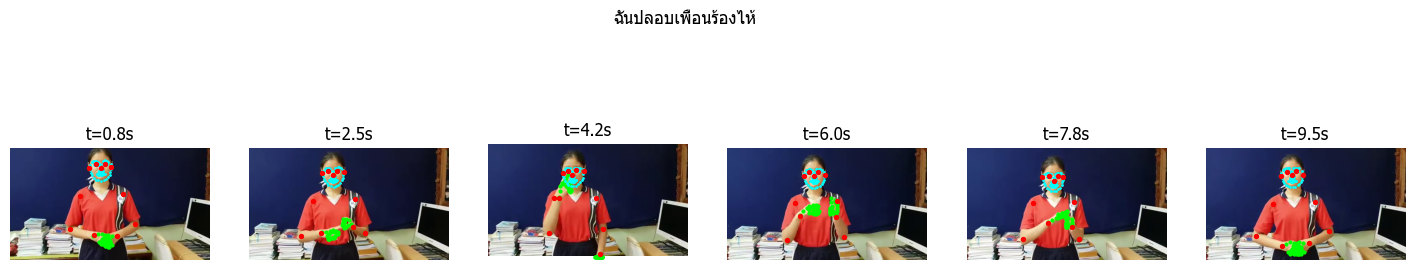

mean hand confidence L/R: 0.899 0.919


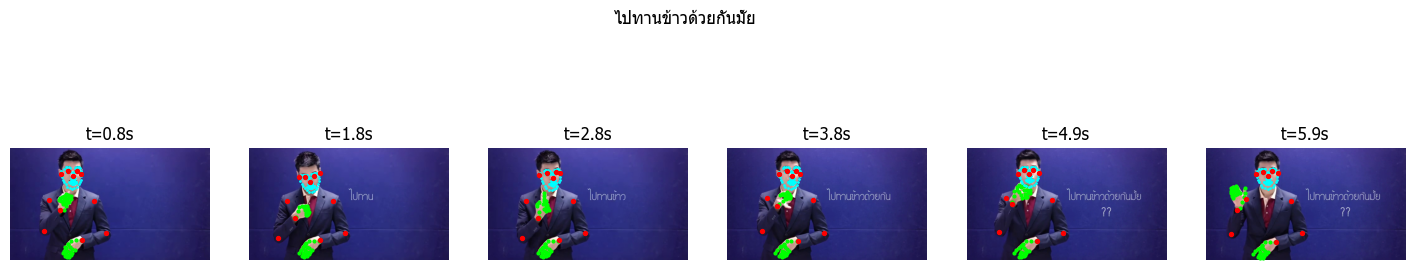

mean hand confidence L/R: 1.027 0.905


In [2]:
from modules.data import decode_frames
import cv2
def draw(stem):
    d = np.load(ART/'pose_v4'/f'test_{stem}_125.npz'); kp, sc = d['kp'], d['sc']
    fr = np.concatenate(list(decode_frames(ROOT/'data_test'/f'{stem}.mp4', fps=12.5))); H, W = fr.shape[1:3]
    fig, ax = plt.subplots(1, 6, figsize=(18, 4))
    for a, i in zip(ax, np.linspace(10, len(fr)-10, 6).astype(int)):
        a.imshow(fr[i][..., ::-1]); ok = sc[i] > 0.3
        a.scatter(kp[i, 91:133, 0][ok[91:133]]*W, kp[i, 91:133, 1][ok[91:133]]*H, s=4, c='lime')
        a.scatter(kp[i, 23:91, 0][ok[23:91]]*W, kp[i, 23:91, 1][ok[23:91]]*H, s=1, c='cyan')
        a.scatter(kp[i, :11, 0][ok[:11]]*W, kp[i, :11, 1][ok[:11]]*H, s=8, c='red'); a.set_title(f't={i/12.5:.1f}s'); a.axis('off')
    plt.suptitle(stem); plt.show()
    print('mean hand confidence L/R:', sc[:, 91:112].mean().round(3), sc[:, 112:133].mean().round(3))
for stem in ['ฉันปลอบเพื่อนร้องไห้', 'ไปทานข้าวด้วยกันมั้ย']:
    draw(stem)

5043 TTRS pose files


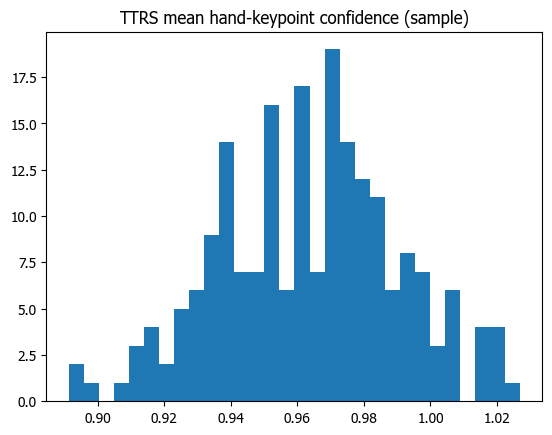

In [3]:
import glob
files = glob.glob(str(ART/'pose_v4'/'ttrs_*.npz'))
conf = [float(np.load(f)['sc'][:, 91:133].astype(np.float32).mean()) for f in files[::25]]
print(len(files), 'TTRS pose files'); plt.hist(conf, bins=30); plt.title('TTRS mean hand-keypoint confidence (sample)'); plt.show()